In [1]:
# Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataframe
df = pd.read_csv('mod_features_df.csv')
df.head()

,query_id,query_contents,query_length,stopword_count,nonstopword_count,stopword_density,nonstopword_density,what,where,when,...,cls_761,cls_762,cls_763,cls_764,cls_765,cls_766,cls_767,best_model,Best Alpha,MRR
0,1048585,what is paula deen's brother,6,2,4,0.333333,0.666667,1,0,0,...,-0.316542,0.164232,-0.089220,-0.071347,-0.031938,0.285646,0.290846,bm25,0.00,0.333333
1,2,Androgen receptor define,3,0,3,0.000000,1.000000,0,0,0,...,-0.050720,0.171317,-0.123599,-0.302324,0.148471,0.649183,-0.100653,splade,0.00,1.000000
2,524332,treating tension headaches without medication,5,0,5,0.000000,1.000000,0,0,0,...,0.088614,0.271708,-0.158394,-0.384479,0.177981,0.435811,-0.153385,repllama,1.00,0.023810
3,1048642,what is paranoid sc,4,2,2,0.500000,0.500000,1,0,0,...,-0.068101,0.137655,-0.179666,-0.398831,-0.017433,0.020971,-0.071258,splade,0.62,0.100000
4,524447,treatment of varicose veins in legs,6,2,4,0.333333,0.666667,0,0,0,...,-0.133143,0.376936,-0.210180,-0.285664,0.195498,0.727291,-0.124383,repllama,0.89,0.024390


In [3]:
df.shape

(6980, 784)

In [4]:
buckets_train = []

for i in range(df.shape[0]):
    if df.iloc[i, 782] >= 0.8:
        buckets_train.append(4)
    elif df.iloc[i, 782] >= 0.6:
        buckets_train.append(3)
    elif df.iloc[i, 782] >= 0.4:
        buckets_train.append(2)
    elif df.iloc[i, 782] >= 0.2:
        buckets_train.append(1)
    else:
        buckets_train.append(0)

df["alpha_buckets"] = buckets_train

In [5]:
# X and y dataframes
X = df.drop(columns=['Best Alpha', 'alpha_buckets', 'query_contents', 'best_model'], axis=1)
y = np.asarray(df['alpha_buckets'], dtype="float64")

X.head()

,query_id,query_length,stopword_count,nonstopword_count,stopword_density,nonstopword_density,what,where,when,why,...,cls_759,cls_760,cls_761,cls_762,cls_763,cls_764,cls_765,cls_766,cls_767,MRR
0,1048585,6,2,4,0.333333,0.666667,1,0,0,0,...,-0.371679,0.132870,-0.316542,0.164232,-0.089220,-0.071347,-0.031938,0.285646,0.290846,0.333333
1,2,3,0,3,0.000000,1.000000,0,0,0,0,...,-0.239406,-0.098719,-0.050720,0.171317,-0.123599,-0.302324,0.148471,0.649183,-0.100653,1.000000
2,524332,5,0,5,0.000000,1.000000,0,0,0,0,...,-0.523775,0.629171,0.088614,0.271708,-0.158394,-0.384479,0.177981,0.435811,-0.153385,0.023810
3,1048642,4,2,2,0.500000,0.500000,1,0,0,0,...,-0.263777,0.258236,-0.068101,0.137655,-0.179666,-0.398831,-0.017433,0.020971,-0.071258,0.100000
4,524447,6,2,4,0.333333,0.666667,0,0,0,0,...,-0.287455,0.245836,-0.133143,0.376936,-0.210180,-0.285664,0.195498,0.727291,-0.124383,0.024390


In [6]:
print(y)

[0. 0. 4. ... 0. 0. 4.]


In [7]:
print(X.shape)

(6980, 781)


In [8]:
buckets = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
bucket_labels = [0, 1, 2, 3, 4]
y_bucketed = np.digitize(y, buckets[1:-1])
y_bucketed = y_bucketed - 1

In [9]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
# Training and testing sets (CHANGE TEST SIZE?)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [11]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size='auto',
    learning_rate='adaptive',
    max_iter=300,
    random_state=42,
    verbose=True
)

In [12]:
print(y_train)

[0. 0. 2. ... 0. 0. 0.]


In [13]:
# Train/fit model
mlp.fit(X_train, y_train)

# Predictions
y_pred = mlp.predict(X_test)

Iteration 1, loss = 1.42706448
Iteration 2, loss = 1.10089988
Iteration 3, loss = 1.02335227


Iteration 4, loss = 0.96472723
Iteration 5, loss = 0.91322628
Iteration 6, loss = 0.86131371
Iteration 7, loss = 0.81530883
Iteration 8, loss = 0.76803418
Iteration 9, loss = 0.72258632
Iteration 10, loss = 0.67564953
Iteration 11, loss = 0.62542000
Iteration 12, loss = 0.58051042
Iteration 13, loss = 0.53515236
Iteration 14, loss = 0.49023641
Iteration 15, loss = 0.44313091
Iteration 16, loss = 0.40514753
Iteration 17, loss = 0.36753857
Iteration 18, loss = 0.32877476
Iteration 19, loss = 0.29183209
Iteration 20, loss = 0.25960054
Iteration 21, loss = 0.23128203
Iteration 22, loss = 0.20032350
Iteration 23, loss = 0.18090782
Iteration 24, loss = 0.15491915
Iteration 25, loss = 0.13497407
Iteration 26, loss = 0.12057328
Iteration 27, loss = 0.10443953
Iteration 28, loss = 0.09004848
Iteration 29, loss = 0.07666033
Iteration 30, loss = 0.06789245
Iteration 31, loss = 0.05889437
Iteration 32, loss = 0.05181782
Iteration 33, loss = 0.04766624
Iteration 34, loss = 0.04207194
Iteration 35, 

Accuracy: 0.5150

Classification Report:
              precision    recall  f1-score   support

         0.0       0.67      0.75      0.70       902
         1.0       0.04      0.02      0.03        93
         2.0       0.04      0.02      0.02       127
         3.0       0.11      0.11      0.11        95
         4.0       0.17      0.18      0.17       179

    accuracy                           0.52      1396
   macro avg       0.20      0.21      0.21      1396
weighted avg       0.46      0.52      0.49      1396


Confusion Matrix:
[[673  32  32  55 110]
 [ 65   2   5   6  15]
 [ 91   6   2   9  19]
 [ 62   4   2  10  17]
 [121   8   6  12  32]]


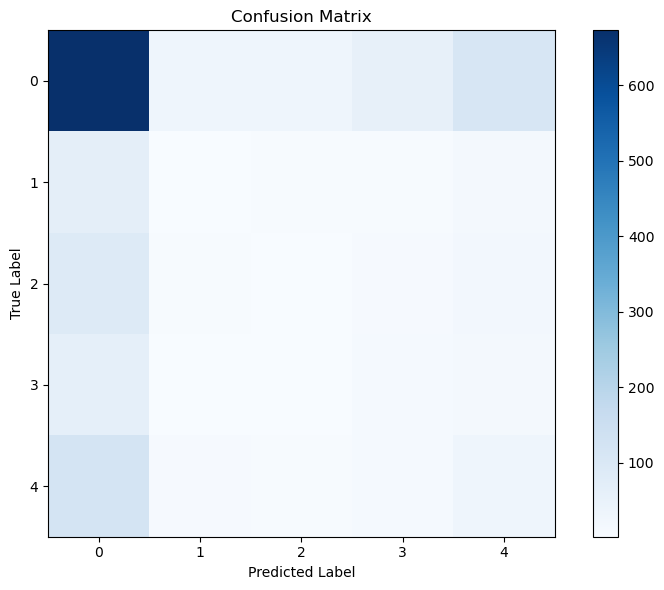

In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(5)
plt.xticks(tick_marks, bucket_labels)
plt.yticks(tick_marks, bucket_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Checking errors
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")


MSE: 4.1089
RMSE: 2.0270
MAE: 1.2951
R²: -0.9004


In [16]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, validation_curve
import seaborn as sns

y_pred_train = mlp.predict(X_train)
y_pred_test = mlp.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"Train MSE: {mse_train:.4f}, Test MSE: {mse_test:.4f}")
print(f"Train R2: {r2_train:.4f}, Test R2: {r2_test:.4f}")

Train MSE: 0.0000, Test MSE: 4.1089
Train R2: 1.0000, Test R2: -0.9004
